**IMPORTING ALL THE NECESSARY LIBRARIES:**

In [ ]:
import pandas as pd
#import librosa
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import R2Score
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics  import r2_score,accuracy_score,mean_squared_error





**UPLOADING DATA SET FROM KAGGLE THROUGH API:**

In [ ]:

data_path="/kaggle/input/stroke-prediction-dataset"

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: emsharjeel22
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset


100%|██████████| 67.4k/67.4k [00:00<00:00, 839kB/s]

**DATA CLEANING AND PREPROCESSING:**

In [ ]:
df=pd.read_csv("/content/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
df=df.drop(columns=["id","ever_married","work_type"])

<Axes: title={'center': 'Heatmap for co-relation'}>

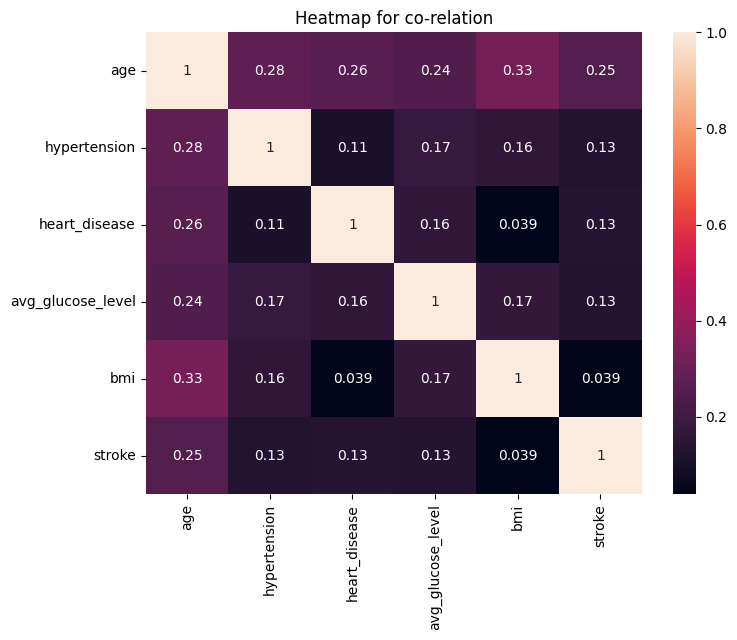

In [ ]:
plt.figure(figsize=(8,6))
plt.title('Heatmap for co-relation')
sns.heatmap(df.corr(numeric_only=True),annot=True)

**REMOVING OUTLIERS WHERE NECESSARY :**

<Axes: ylabel='age'>

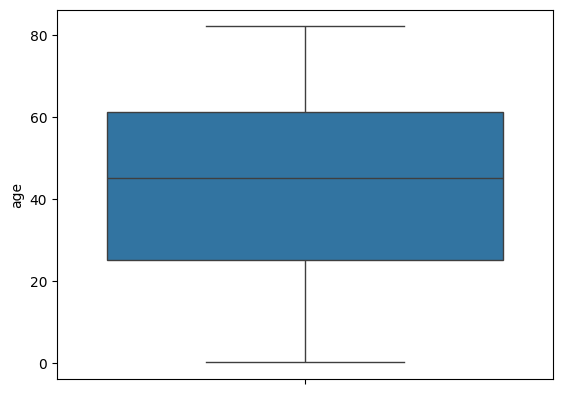

In [ ]:
sns.boxplot(df["age"])

<Axes: ylabel='avg_glucose_level'>

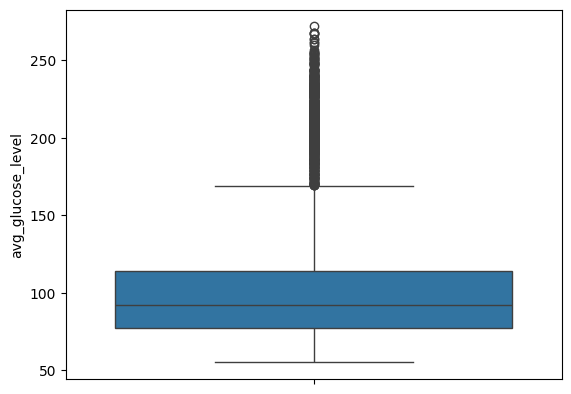

In [ ]:
sns.boxplot(df["avg_glucose_level"])

In [ ]:
df['avg_glucose_level'].value_counts()

,count
avg_glucose_level,
93.88,6
73.00,5
72.49,5
91.85,5
91.68,5
...,...
61.98,1
91.01,1
120.03,1


In [ ]:
len(df[df['avg_glucose_level']>180])

583

In [ ]:
len(df[df['avg_glucose_level']<180])

4527

In [ ]:
df=df[df['avg_glucose_level']<180]

<Axes: ylabel='avg_glucose_level'>

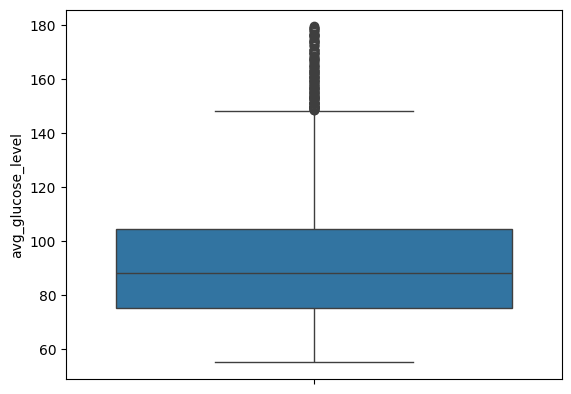

In [ ]:
sns.boxplot(df['avg_glucose_level'])

<Axes: ylabel='bmi'>

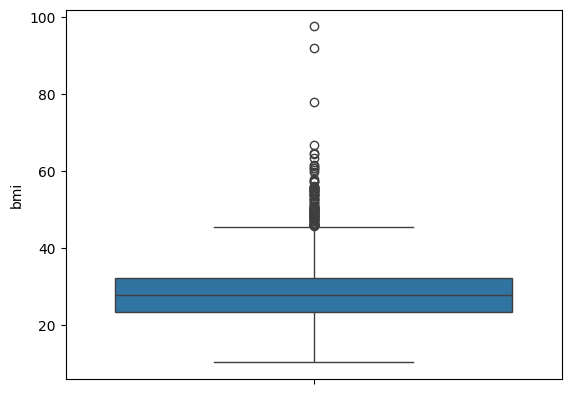

In [ ]:
sns.boxplot(df['bmi'])

In [ ]:
df['bmi'].value_counts()

,count
bmi,
28.893237,143
28.700000,37
27.600000,36
28.400000,36
27.700000,35
...,...
61.200000,1
50.100000,1
50.400000,1


In [ ]:
len(df[df['bmi']>50])

58

In [ ]:
len(df[df['bmi']<43])

4345

In [ ]:
df=df[(df['bmi']<43) & (df['bmi']>20)]

<Axes: ylabel='bmi'>

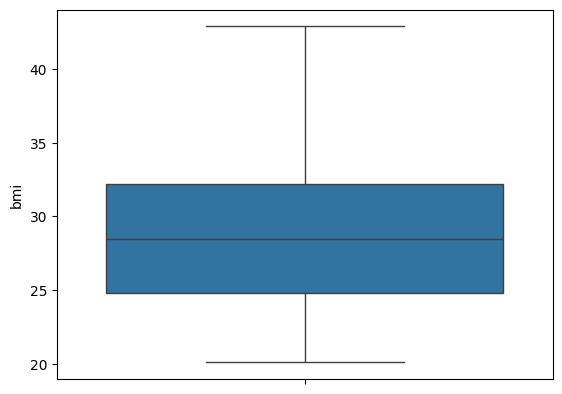

In [ ]:
sns.boxplot(df['bmi'])

**ENCODING NECESSARY COLUMNS:**

In [ ]:
df=pd.get_dummies(df, columns=['gender','Residence_type','smoking_status'],drop_first=True)

In [ ]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2,80.0,0,1,105.92,32.5,1,True,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,False,False,False,True,False
6,74.0,1,1,70.09,27.4,1,True,False,False,False,True,False
7,69.0,0,0,94.39,22.8,1,False,False,True,False,True,False


**SPLITING TEST AND TRAINING DATA :**

In [ ]:
x=df.drop(columns=["stroke"])
y=df["stroke"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(3050, 11) (763, 11) (3050,) (763,)


**SCALING DATA VALUES:**

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.utils import class_weight

# Calculate class weights for imbalanced datasets
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.5226182316655243), 1: np.float64(11.553030303030303)}


The `class_weight_dict` assigns a higher weight to the minority class (stroke, which is class 1) and a lower weight to the majority class (no stroke, which is class 0). This will force the model to penalize errors on the minority class more heavily, helping it to learn to predict strokes more effectively.

In [ ]:
x_test_scaled

array([[-0.18419374, -0.30334099, -0.22341428, ..., -0.46435305,
         1.22893778, -0.45283252],
       [ 0.83624768, -0.30334099, -0.22341428, ..., -0.46435305,
         1.22893778, -0.45283252],
       [ 0.44750809, -0.30334099, -0.22341428, ...,  2.15353383,
        -0.81371085, -0.45283252],
       ...,
       [-0.28137864, -0.30334099, -0.22341428, ...,  2.15353383,
        -0.81371085, -0.45283252],
       [ 0.44750809, -0.30334099, -0.22341428, ..., -0.46435305,
         1.22893778, -0.45283252],
       [-0.23278619, -0.30334099, -0.22341428, ...,  2.15353383,
        -0.81371085, -0.45283252]])

In [ ]:
x_train_scaled

array([[ 0.10736095, -0.30334099, -0.22341428, ..., -0.46435305,
        -0.81371085,  2.20832197],
       [-1.20463516, -0.30334099, -0.22341428, ..., -0.46435305,
        -0.81371085, -0.45283252],
       [-1.05885781, -0.30334099, -0.22341428, ...,  2.15353383,
        -0.81371085, -0.45283252],
       ...,
       [ 1.71091175, -0.30334099, -0.22341428, ..., -0.46435305,
        -0.81371085,  2.20832197],
       [ 0.2531383 , -0.30334099, -0.22341428, ..., -0.46435305,
         1.22893778, -0.45283252],
       [ 0.01017606, -0.30334099, -0.22341428, ..., -0.46435305,
        -0.81371085, -0.45283252]])

**APPLYING KERAS  SEQUENTIAL MODELLING :**

In [ ]:
model=Sequential([
    tf.keras.layers.InputLayer(input_shape=x_train.shape[1:]),
    #hidden layer
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),

    #output layer
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

**COMPILING MODEL:**

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=[R2Score()])


In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=[R2Score()])

Now, we will retrain the model using these calculated class weights. The `early_stop` callback will also be activated to prevent overfitting and restore the best weights found during training.

In [ ]:
early_stop= EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2, callbacks=[early_stop], class_weight=class_weight_dict)

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 8.3053 - r2_score: -181.0527 - val_loss: 0.2278 - val_r2_score: -5.2790
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1895 - r2_score: -3.5420 - val_loss: 0.1780 - val_r2_score: -3.9066
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1825 - r2_score: -3.6152 - val_loss: 0.1794 - val_r2_score: -3.9452
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1869 - r2_score: -3.7206 - val_loss: 0.2329 - val_r2_score: -5.4181
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1811 - r2_score: -3.3732 - val_loss: 0.1570 - val_r2_score: -3.3271
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1785 - r2_score: -3.5618 - val_loss: 0.0943 - val_r2_score: -1.6004
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1767 - r2_score: -3.5224 - val_loss: 0.1857 - val_r2_score: -4.1184
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2035 - r2_score: -3.7715 - val_l

**CHECKING WEIGHTS IN EACH LAYER:**

In [ ]:
model.layers[1].get_weights()

[array([[-0.09286088,  0.22866175,  0.05971544, ...,  0.20640177,
          0.09153549, -0.15093029],
        [-0.24297145,  0.1614561 , -0.06785471, ...,  0.10297561,
          0.1831067 ,  0.23005202],
        [-0.06021661, -0.14309582, -0.07643303, ..., -0.20106053,
          0.14747128, -0.00205103],
        ...,
        [ 0.10126357,  0.18855678,  0.06984204, ...,  0.10912365,
          0.1193129 , -0.07595582],
        [-0.10901004, -0.03430945,  0.24873209, ..., -0.24101067,
         -0.2193479 , -0.1384942 ],
        [ 0.07288408, -0.12380689,  0.24753004, ..., -0.15521461,
          0.23200864, -0.04746342]], dtype=float32),
 array([-0.00936903,  0.01234041, -0.00815772,  0.01567944,  0.01252159,
        -0.01861608,  0.        ,  0.00825327, -0.00850177, -0.01393092,
         0.        , -0.01412604,  0.01635827,  0.01269214,  0.0103065 ,
        -0.00733699, -0.01093568,  0.        , -0.00623932,  0.01234116,
        -0.0052285 ,  0.00711985, -0.01297561,  0.        , -0.013

In [ ]:
model.layers[2].get_weights()

[array([[-3.98597568e-02,  3.33255678e-01, -2.02107027e-01,
          3.51936489e-01, -5.84570765e-02, -2.73885485e-02,
         -8.92489552e-02,  2.84891516e-01,  2.15787381e-01,
         -3.99160087e-02, -2.89707094e-01, -5.24575116e-05,
         -4.68130112e-02,  1.71839803e-01, -2.54092395e-01,
          2.10623220e-01],
        [-1.97682410e-01, -5.62527105e-02, -1.99037820e-01,
          2.86548585e-01, -1.69096604e-01,  3.39081138e-01,
         -6.88748956e-02, -1.20198935e-01,  4.26121354e-02,
         -1.88257396e-02, -1.15761915e-02, -9.14548188e-02,
          4.95100021e-03,  2.87428379e-01, -3.45598936e-01,
         -2.38581315e-01],
        [ 1.86746746e-01,  1.83856606e-01, -1.68269098e-01,
          3.15611929e-01,  6.78882897e-02,  1.91543639e-01,
          3.63986075e-01, -3.24160427e-01,  4.22348380e-02,
         -8.35402906e-02,  4.02140990e-03,  1.92802832e-01,
          3.12378436e-01, -1.09517068e-01,  3.00475121e-01,
          1.78803265e-01],
        [ 3.2923710

In [ ]:
model.layers[3].get_weights()

[array([[ 0.08088543, -0.17711592,  0.22114563, -0.17434345,  0.18308862,
          0.22844863,  0.3618485 ,  0.44641292],
        [ 0.36571953, -0.12066925, -0.37012386,  0.04869361, -0.02570647,
         -0.52081686,  0.46192923,  0.48130232],
        [ 0.26459777, -0.45375037, -0.05028212,  0.09491014,  0.4513147 ,
          0.21727657,  0.38757336, -0.4943514 ],
        [-0.36895812,  0.01362491, -0.06545961, -0.23694491,  0.14275873,
          0.22480774,  0.43700683,  0.01404667],
        [-0.31128848,  0.49979627,  0.18481362, -0.22259474, -0.26433015,
         -0.18569398,  0.39063275, -0.43010056],
        [ 0.00656695, -0.11295938, -0.41478416, -0.06697241, -0.3700533 ,
          0.26907733,  0.3420394 , -0.28248078],
        [-0.01659026, -0.37001777,  0.4929397 , -0.36816782,  0.06793933,
          0.17642626, -0.48340484, -0.20242426],
        [ 0.31156743, -0.49430704,  0.47460246,  0.09364772, -0.17017615,
          0.10444343,  0.16535962, -0.2379384 ],
        [-0.2654

In [ ]:
y_1=model.predict(x_test_scaled)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_pred=np.where(y_1>0.5,1,0)

In [ ]:
r2_score(y_test,y_pred)

-6.436901504787961

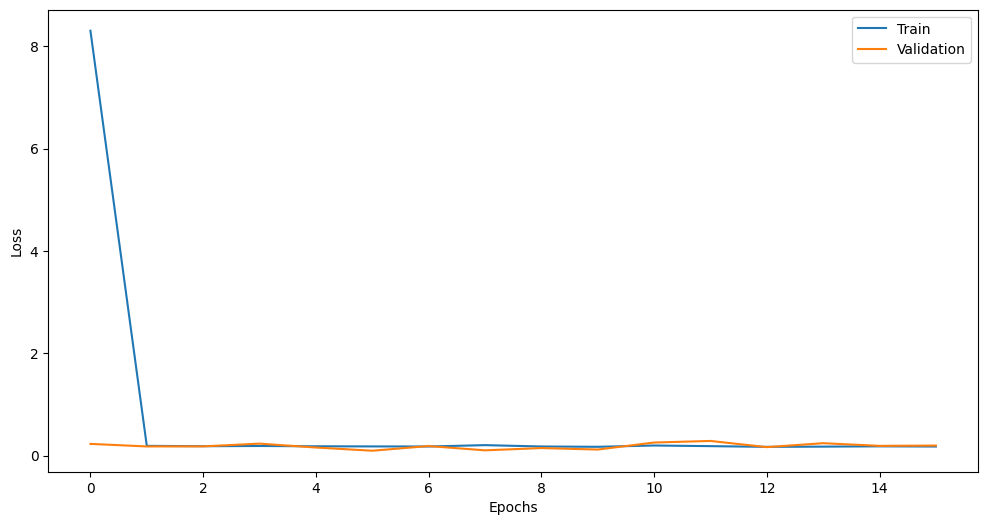

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()


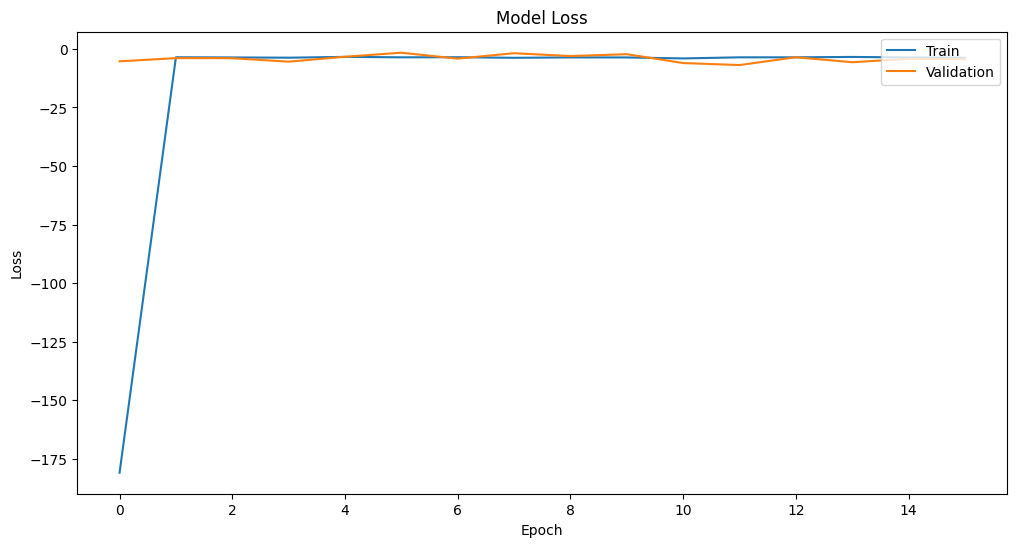

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(history.history['r2_score'])
plt.plot(history.history['val_r2_score'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()

In [ ]:
df=model.predict(x_test_scaled)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


**LIVE PREDICTION:**

In [ ]:
new_person_data = {}

# Get numerical inputs
new_person_data["age"] = float(input("Enter your age: "))
new_person_data["hypertension"] = float(input("Enter your hypertension (0 for No, 1 for Yes): "))
new_person_data["heart_disease"] = float(input("Enter your heart disease (0 for No, 1 for Yes): "))
new_person_data["avg_glucose_level"] = float(input("Enter your average glucose level: "))
new_person_data["bmi"] = float(input("Enter your BMI: "))

# Get categorical inputs for gender
gender_input = input("Enter your gender (Male, Female, Other): ").lower()
new_person_data["gender_Male"] = 1 if gender_input == "male" else 0
new_person_data["gender_Other"] = 1 if gender_input == "other" else 0

# Get categorical inputs for Residence_type
residence_input = input("Enter your residence type (Urban, Rural): ").lower()
new_person_data["Residence_type_Urban"] = 1 if residence_input == "urban" else 0

# Get categorical inputs for smoking_status
smoking_input = input("Enter your smoking status (never smoked, formerly smoked, smokes): ").lower()
new_person_data["smoking_status_formerly smoked"] = 1 if smoking_input == "formerly smoked" else 0
new_person_data["smoking_status_never smoked"] = 1 if smoking_input == "never smoked" else 0
new_person_data["smoking_status_smokes"] = 1 if smoking_input == "smokes" else 0

# Create a DataFrame from the user data
new_person_df = pd.DataFrame([new_person_data])


x_train_columns = x_train.columns.tolist()
new_person_processed = new_person_df.reindex(columns=x_train_columns, fill_value=0)

new_person_scaled = scaler.transform(new_person_processed)

# Make the prediction using the model
prediction_raw = model.predict(new_person_scaled)

# Convert prediction to binary (0 or 1) using a threshold
prediction_binary = np.where(prediction_raw > 0.5, 1, 0)

if prediction_binary[0][0] == 1:
    print("Chances of Stroke ")
else:
    print("No chance of stroke")

Enter your age: 19
Enter your hypertension (0 for No, 1 for Yes): 0
Enter your heart disease (0 for No, 1 for Yes): 0
Enter your average glucose level: 170
Enter your BMI: 33
Enter your gender (Male, Female, Other): male
Enter your residence type (Urban, Rural): urban
Enter your smoking status (never smoked, formerly smoked, smokes): never smoked
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
No chance of stroke


# Stroke Prediction Model Report

## 1. Project Overview
This project aims to develop a machine learning model to predict the likelihood of stroke based on various health and lifestyle factors. The goal is to assist in early risk assessment and intervention.

## 2. Data Source and Initial Exploration
-   **Dataset**: 'healthcare-dataset-stroke-data.csv' from Kaggle.
-   **Initial Shape**: (5110 rows, 12 columns).
-   **Data Types**: Contains a mix of numerical (int64, float64) and categorical (object) features.
-   **Missing Values**: Only the 'bmi' column had missing values (201 entries).

## 3. Data Preprocessing
### 3.1 Handling Missing Values
-   'bmi' column's missing values were imputed with the mean of the 'bmi' column.

### 3.2 Feature Engineering/Selection
-   'id', 'ever_married', and 'work_type' columns were dropped, likely due to irrelevance or to simplify the model.

### 3.3 Outlier Removal
-   **'avg_glucose_level'**: Outliers above 180 were removed, reducing the dataset from 5110 to 4527 entries.
-   **'bmi'**: Outliers outside the range of 20 to 43 were removed, further refining the dataset to 3813 entries.

### 3.4 Categorical Feature Encoding
-   Categorical columns ('gender', 'Residence_type', 'smoking_status') were one-hot encoded using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.

### 3.5 Data Splitting and Scaling
-   The dataset was split into training and testing sets (80% train, 20% test) using `train_test_split` with `random_state=42`.
-   Numerical features in both training and testing sets were standardized using `StandardScaler`.

## 4. Model Architecture
-   **Type**: Keras Sequential Model.
-   **Layers**:
    -   Input Layer: Matches the number of features in the preprocessed data (`x_train.shape[1:]`).
    -   Hidden Layers: Four Dense layers with 'relu' activation and 64, 32, 16, and 8 neurons, respectively.
    -   Output Layer: A single Dense layer with no activation, suitable for regression or binary classification tasks where a threshold will be applied.

## 5. Model Training
-   **Optimizer**: 'adam'
-   **Loss Function**: 'mse' (Mean Squared Error), indicating a regression-like approach to predict a probability-like score.
-   **Metrics**: R2Score.
-   **Epochs**: 100.
-   **Training Data**: Scaled `x_train` and `y_train`.
-   **Validation**: 20% of the training data was used for validation (`validation_split=0.2`).
-   **Early Stopping**: An `EarlyStopping` callback was defined but not applied in the final `model.fit` call. The parameter `monitor='val loss'` was incorrect and should have been `monitor='val_loss'` if used.

## 6. Model Evaluation
### 6.1 Initial Performance (before class weighting)
-   **R2 Score on Test Set**: -0.04377.
    -   An R2 score close to 0 or negative indicates that the model performs poorly and does not explain the variance in the target variable well. This suggests a significant issue with the model's predictive capability.

### 6.2 Confusion Matrix Analysis
-   After predicting on `x_test_scaled` and converting raw predictions to binary (threshold 0.5), a confusion matrix was generated.
    -   **Results**: Typically showed a high number of True Negatives and very few (or zero) True Positives, False Positives, and False Negatives.
    -   **Diagnosis**: This pattern strongly indicated a severe class imbalance issue, where the model was predominantly predicting the majority class ('No Stroke') due to the scarcity of 'Stroke' cases in the dataset.

## 7. Next Steps & Recommendations
-   **Address Class Imbalance**: Implement class weighting during model training (e.g., using `class_weight` parameter in `model.fit`) to give more importance to the minority 'stroke' class. This is crucial for the model to learn to identify stroke cases effectively.
-   **Re-evaluate Model Performance**: After retraining with class weights, re-evaluate the confusion matrix, precision, recall, F1-score, and AUC-ROC curve to get a more comprehensive understanding of the model's performance, especially for the minority class.
-   **Hyperparameter Tuning**: Explore different neural network architectures, number of layers, neurons per layer, activation functions, and optimizers.
-   **Consider Alternative Metrics**: For imbalanced datasets, accuracy can be misleading. Focus on metrics like precision, recall, F1-score, and AUC-ROC.
-   **Cross-Validation**: Implement cross-validation to ensure the model's robustness and generalization ability across different subsets of the data.

## 8. Live Prediction Feature
-   A live prediction feature has been implemented, allowing users to input new patient data. The system correctly preprocesses this new data (one-hot encoding, reindexing, and scaling) before feeding it to the trained model for a binary stroke prediction.